In [2]:
# Bivariate Analysis

In [3]:
# - Numerical vs numerical: scatter plot, correlation
# - Numerical vs categorical: boxplot, group statistics
# - Categorical vs categorical: crosstab, countplot

In [4]:
%pip install -q pandas numpy seaborn matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
df = pd.read_csv("titanic_dataset.csv")

In [3]:
df.shape

(891, 15)

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

| Column        | Description                                        | Feature Type                |
|---------------|----------------------------------------------------|-----------------------------|
| survived      | Whether the passenger survived (1) or not (0)      | Numerical (binary)          |
| pclass        | Passenger travel class (1, 2, 3)                   | Numerical (categorical encoded) |
| sex           | Passenger gender                                   | Categorical                 |
| age           | Passenger age in years                             | Numerical                   |
| sibsp         | Number of siblings or spouses aboard               | Numerical                   |
| parch         | Number of parents or children aboard               | Numerical                   |
| fare          | Ticket fare paid                                   | Numerical                   |
| embarked      | Port where passenger boarded (C, Q, S)             | Categorical                 |
| class         | Passenger class label (First, Second, Third)       | Categorical                 |
| who           | Person type (man, woman, child)                    | Categorical                 |
| adult_male    | Whether passenger is an adult male (True or False) | Categorical (boolean)       |
| deck          | Deck letter where cabin is located                 | Categorical                 |
| embark_town   | Town corresponding to embark point                 | Categorical                 |
| alive         | Survival status (yes or no) (repeated)             | Categorical                 |
| alone         | Whether the passenger traveled alone               | Categorical (boolean)       |

In [6]:
# Identify numerical and categorical features
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["survived", "pclass", "sex", "embarked", "class", "who", "adult_male", "deck", "embark_town", "alone"]

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


In [7]:
df_num = df[num_cols].dropna()

In [8]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [11]:
df["survived_label"] = df["survived"].map({0: "No", 1: "Yes"})

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


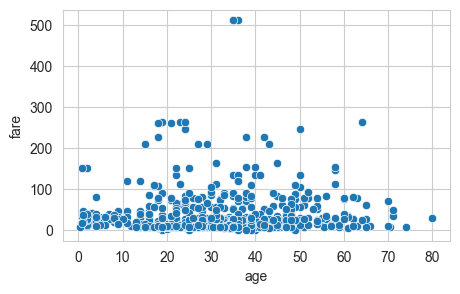

In [ ]:
# Scatter Plot
plt.figure(figsize=(5,3))
sns.scatterplot(x=df["age"], y=df["fare"])
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

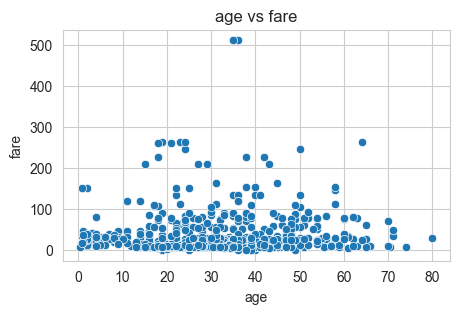

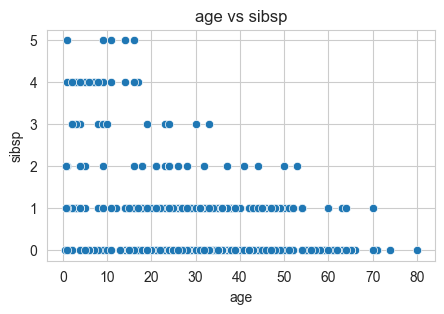

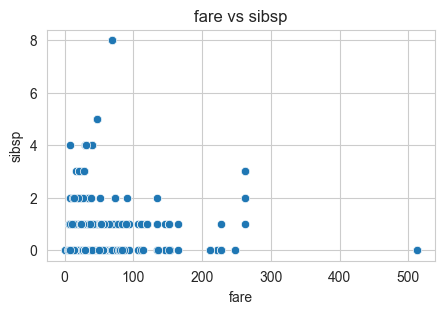

In [13]:
num_pairs = [
    ("age", "fare"),
    ("age", "sibsp"),
    ("fare", "sibsp")
]

for x, y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [ ]:
# Correlation Matrix
print("Correlation Matrix")
df_num.corr()

# -1 -> high negative correlation; +1 -> high positive correlation

Correlation Matrix


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [ ]:
print("Pearson Correlation with fare:")
for col in num_cols:
    if col != "fare":
        r, p = pearsonr(df_num[col], df_num["fare"])
        print(f"{col} vs fare: r={r:.3f}; p={p:.3f}")

# r, p; r -> correlation coefficient (-1 to +1); p -> small val (0.05) -> strong confidence; high -> random coincidence 

Pearson Correlation with fare:
age vs fare: r=0.096; p=0.010
sibsp vs fare: r=0.138; p=0.000
parch vs fare: r=0.205; p=0.000


In [13]:
# Numerical vs Categorical Features

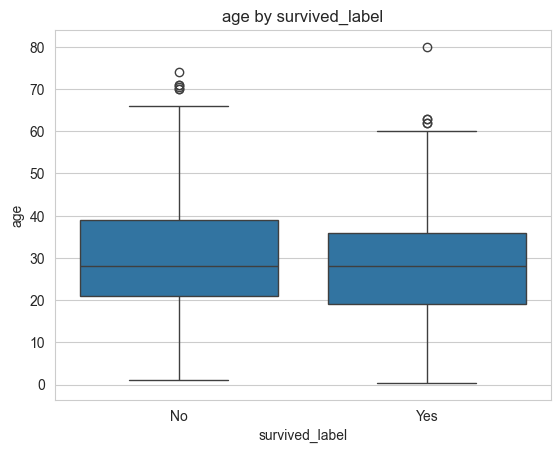

In [14]:
# Boxplots
plt.Figure(figsize=(5,3))
sns.boxplot(x=df["survived_label"], y=df["age"])
plt.xlabel("survived_label")
plt.ylabel("age")
plt.title("age by survived_label")
plt.show()

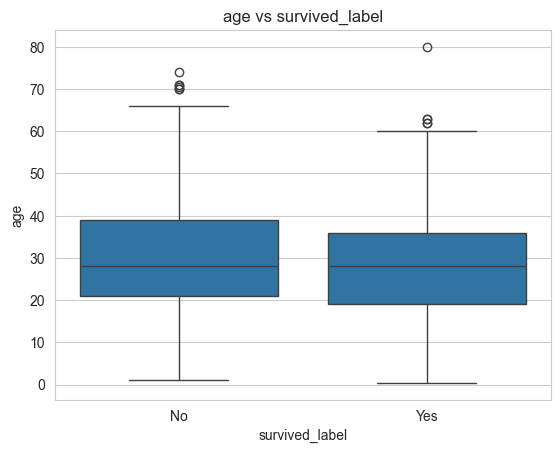

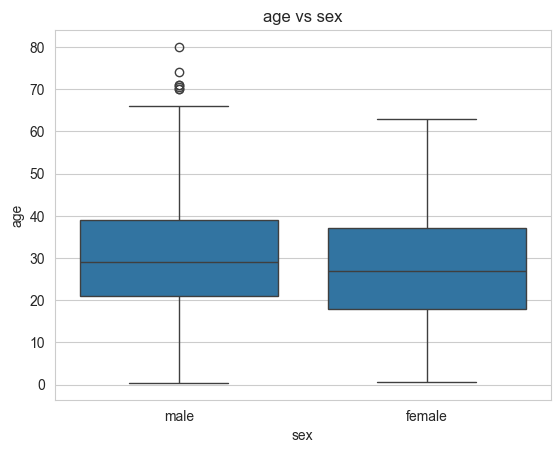

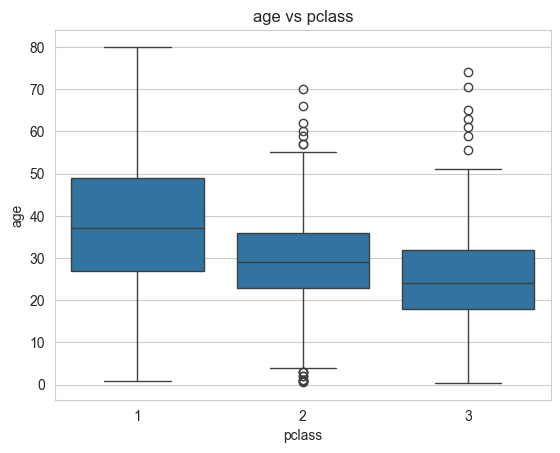

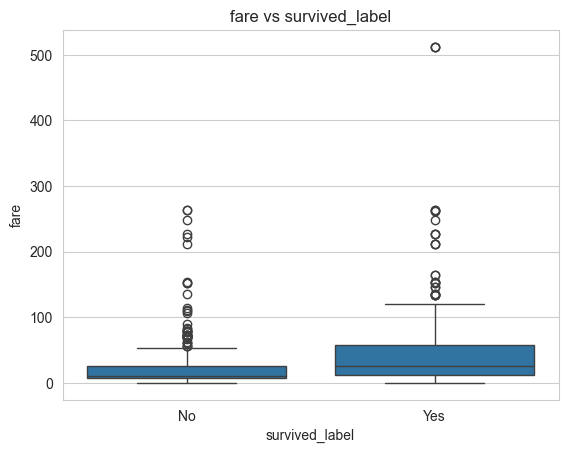

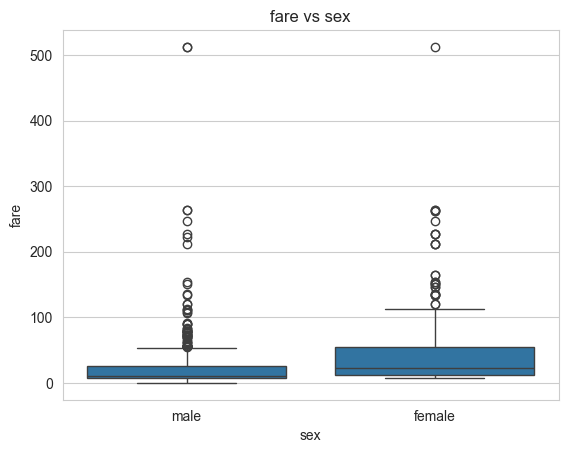

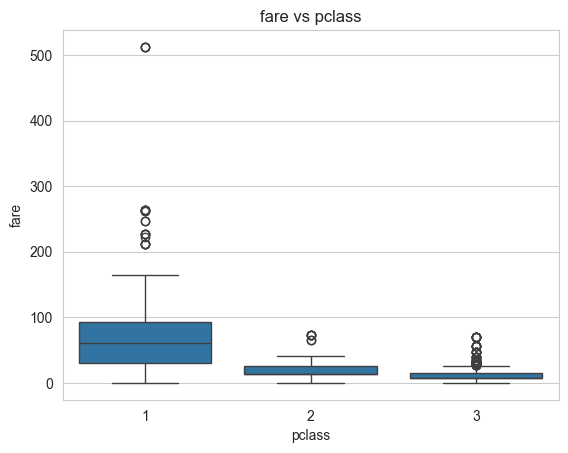

In [ ]:
num_for_box = ["age", "fare"]
cat_for_box = ["survived_label", "sex", "pclass"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.Figure(figsize=(5,3))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

In [ ]:
# Grouped Statistics
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [21]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'survived_label'],
      dtype='object')

In [26]:
df[num_cols + ["survived_label"]]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,No
1,38.0,71.2833,1,0,Yes
2,26.0,7.9250,0,0,Yes
3,35.0,53.1000,1,0,Yes
4,35.0,8.0500,0,0,No
...,...,...,...,...,...
886,27.0,13.0000,0,0,No
887,19.0,30.0000,0,0,Yes
888,NaN,23.4500,1,2,No
889,26.0,30.0000,0,0,Yes


In [27]:
df[num_cols + ["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
No,30.626179,22.117887,0.553734,0.329690
Yes,28.343690,48.395408,0.473684,0.464912


In [30]:
for cat in ["survived_label", "sex", "pclass"]:
    print(f"Grouped Statistics for fare by {cat}:")
    # print(df.groupby(cat)["fare"].describe())
    print(df.groupby(cat)["fare"].mean())
    print("-"*50)


Grouped Statistics for fare by survived_label:
survived_label
No     22.117887
Yes    48.395408
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by pclass:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
--------------------------------------------------


In [15]:
# Categorical vs Categorical features

In [16]:
# Crosstab examples
print("Crosstab: sex vs survived")
print(pd.crosstab(df["sex"], df["survived_label"]))

print("Crosstab: pclass vs survived")
print(pd.crosstab(df["pclass"], df["survived_label"]))

Crosstab: sex vs survived
survived_label   No  Yes
sex                     
female           81  233
male            468  109
Crosstab: pclass vs survived
survived_label   No  Yes
pclass                  
1                80  136
2                97   87
3               372  119


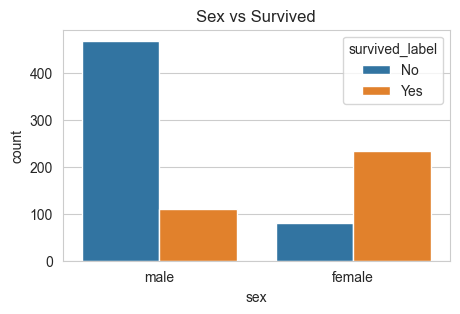

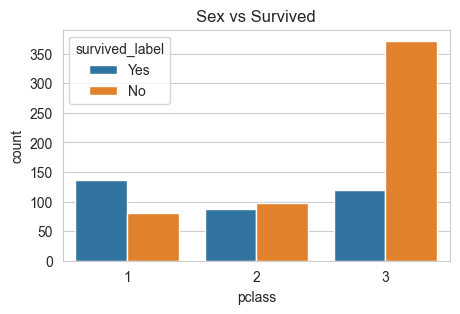

In [17]:
# Countplot
plt.figure(figsize=(5,3))
sns.countplot(x=df["sex"], hue=df["survived_label"])
plt.title("Sex vs Survived")
plt.show()


plt.figure(figsize=(5,3))
sns.countplot(x=df["pclass"], hue=df["survived_label"])
plt.title("Sex vs Survived")
plt.show()

In [18]:
# Summary
print("\nBivariate Analysis Completed")
print("- Numerical vs numerical: scatter + correlations")
print("- Numerical vs categorical: boxplots + group stats")
print("- Categorical vs categorical: crosstab + countplot")



Bivariate Analysis Completed
- Numerical vs numerical: scatter + correlations
- Numerical vs categorical: boxplots + group stats
- Categorical vs categorical: crosstab + countplot


In [19]:
# Bivariate analysis shows how features interact with each other and reveals patterns that single feature analysis cannot capture.

# Numerical relationships are mostly weak, with low correlation values. This means age, fare, sibsp, and parch behave independently and do not cause multicollinearity.
# Fare strongly interacts with survival, sex, and class, making it an important predictive feature.
# Passenger class, sex, and embarked categories show clear separation in survival outcomes. These categorical interactions will be captured strongly by tree models.
# Grouped statistics show survival increases with higher fare and better travel class, reinforcing socioeconomic influence.
# Crosstabs highlight the strongest categorical drivers, especially sex and pclass.

# Overall, bivariate analysis helps us confirm which pairs of features are most informative, guides feature engineering, and reveals the interactions that will matter most in machine learning models.